# sachsfield Demo

Demonstrates the scalar field evolution package for the Sachs optical equations:
$$\dot{x}_a = F_{abc}\, x_b\, x_c + s_a$$

Decomposed into saddle point $\chi_a(\lambda)$ + fluctuations $\xi_a(\lambda, n)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os

# Add parent directory to path so we can import sachsfield
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import sachsfield as sf

## 1. Saddle Point — Verify analytic solution

With zero source $\bar{s}_a = 0$ and $F_{111} = -1/2$, the exact solution is $\chi_1 = 2/\lambda$, $\chi_{2,3} = 0$.

The rescaled variable $y_1 = \lambda \chi_1$ stays $O(1)$ (here exactly 2).

In [34]:
# Zero source
def sbar_zero(lam):
    result= np.zeros(3)
    result[0] = - 1  # sbar_1 = 1
    return result

lam_start = 1e-4
lam_end = 10.0

sp_solver = sf.SaddlePointSolver(
    sbar_zero, lam_span=(lam_start, lam_end),
    n_fields=3, y1_init=2.0,  # chi_1 -> 2/lam asymptotically
    rtol=1e-6, atol=1e-8,

)
sp_result = sp_solver.solve()

# Compare to exact solution chi_1 = 2/lam
lam = sp_result.lam
chi_exact = 2.0 / lam

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lam, sp_result.chi[0], 'b-', label=r'$\chi_1$ (numerical)')
axes[0].plot(lam, chi_exact, 'r--', label=r'$2/\lambda$ (asymptotic)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel(r'$\lambda$')
axes[0].set_ylabel(r'$\chi_1$')
axes[0].legend()
axes[0].set_title('Saddle point: zero source')

# Relative error
rel_err = np.abs(sp_result.chi[0] - chi_exact) / np.abs(chi_exact)
axes[1].semilogy(lam, rel_err)
axes[1].set_xlabel(r'$\lambda$')
axes[1].set_ylabel('Relative error')
axes[1].set_title(r'$|\chi_1^{\rm num} - 2/\lambda| / |2/\lambda|$')

plt.tight_layout()
plt.show()


RuntimeError: Saddle-point integration failed: Required step size is less than spacing between numbers.

Text(0.5, 1.0, 'Singular ODE solution')

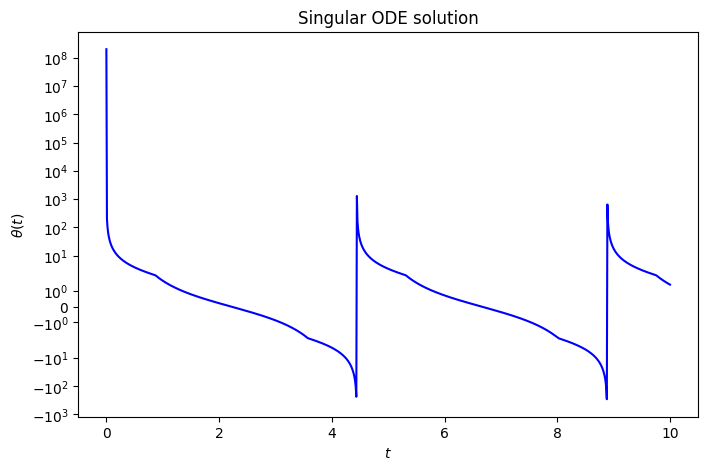

In [35]:
import numpy as np
from scipy.integrate import solve_ivp


def solve_singular_theta(s, t_max, epsilon=1e-8, num_points=1000, method="Radau"):
    """
    Solve the singular Riccati-type ODE

        dtheta/dt = -0.5 * theta(t)^2 + s(t),   t in (0, t_max],

    with singular initial behavior

        theta(t) ~ 2 / t   as t -> 0+.

    Method
    ------
    Directly integrating theta is numerically unstable near t = 0 because of the
    singularity. Instead, use the substitution

        theta(t) = 2 u'(t) / u(t),

    which transforms the equation into the linear second-order ODE

        u''(t) = 0.5 * s(t) * u(t).

    To match theta(t) ~ 2/t near the origin, we require

        2 u'(t) / u(t) ~ 2 / t,

    so that u'(t) / u(t) ~ 1 / t, hence u(t) ~ C t. We may take C = 1, giving
    the initial data at a small epsilon > 0:

        u(epsilon)  = epsilon,
        u'(epsilon) = 1.

    Parameters
    ----------
    s : callable
        Source term s(t). Should accept a scalar float t and return a scalar.
        Vectorized callables are also supported.
    t_max : float
        Final integration time. Must satisfy t_max > epsilon > 0.
    epsilon : float, optional
        Small positive starting time used to avoid the singular point t = 0.
        Default is 1e-6.
    num_points : int, optional
        Number of output sample points in [epsilon, t_max]. Default is 1000.
    method : str, optional
        Integration method passed to scipy.integrate.solve_ivp. Default is "DOP853".

    Returns
    -------
    t : ndarray, shape (num_points,)
        Time samples in [epsilon, t_max].
    theta : ndarray, shape (num_points,)
        Reconstructed solution theta(t) = 2 u'(t) / u(t).

    Raises
    ------
    ValueError
        If input parameters are invalid.
    RuntimeError
        If the ODE solver fails.

    Notes
    -----
    Numerical stability measures:
    - Integration starts at t = epsilon, not at t = 0.
    - theta is reconstructed only where |u(t)| is safely above a small threshold.
    - Near any accidental zero crossing of u, theta is set to NaN to avoid
      division-by-zero or catastrophic blow-up.

    Examples
    --------
    Solve with s(t) = 0, for which the exact singular solution is theta(t) = 2/t:

    >>> t, theta = solve_singular_theta(lambda t: 0.0, t_max=1.0)

    Solve with constant forcing s(t) = 1:

    >>> t, theta = solve_singular_theta(lambda t: 1.0, t_max=1.0)
    """
    if not callable(s):
        raise ValueError("s must be a callable.")
    if epsilon <= 0:
        raise ValueError("epsilon must be positive.")
    if t_max <= epsilon:
        raise ValueError("t_max must be greater than epsilon.")
    if num_points < 2:
        raise ValueError("num_points must be at least 2.")

    t_eval = np.linspace(epsilon, t_max, num_points)

    def _s_scalar(t):
        """
        Evaluate s(t) robustly for scalar t.

        Supports both scalar-only and vectorized user callables.
        """
        val = s(t)
        arr = np.asarray(val)
        if arr.ndim == 0:
            return float(arr)
        return float(arr.reshape(-1)[0])

    def rhs(t, y):
        """
        First-order system for y = [u, u']:

            u'  = v
            v'  = 0.5 * s(t) * u
        """
        u, up = y
        return np.array([up, 0.5 * _s_scalar(t) * u], dtype=float)

    # Initial data chosen so that u(t) ~ t near t = 0+,
    # which gives theta(t) = 2 u'(t)/u(t) ~ 2/t.
    u0 = float(epsilon)
    up0 = 1.0

    sol = solve_ivp(
        rhs,
        (epsilon, t_max),
        y0=np.array([u0, up0], dtype=float),
        t_eval=t_eval,
        method=method,
        rtol=1e-9,
        atol=1e-12,
    )

    if not sol.success:
        raise RuntimeError(f"ODE solve failed: {sol.message}")

    t = sol.t
    u = sol.y[0]
    up = sol.y[1]

    # Avoid division-by-zero: if u gets too small, mark theta as NaN.
    scale = max(1.0, np.max(np.abs(u)))
    u_floor = 1e-14 * scale

    theta = np.full_like(u, np.nan, dtype=float)
    safe = np.abs(u) > u_floor
    theta[safe] = 2.0 * up[safe] / u[safe]

    return t, theta


def fun_s(t):
    return -1


# Example 1: s(t) = 0, exact singular solution is theta(t) = 2/t.
t0, theta0 = solve_singular_theta(fun_s, t_max=10.0, num_points=1000, 
                                  method="Radau"
                                  )


plt.figure(figsize=(8, 5))
plt.plot(t0, theta0, 'b-', label='implementation 1')
plt.yscale('symlog')
# plt.plot(lam, sp_result.chi[0], 'r--', label='implementation 2')
# plt.xlim(6)
plt.xlabel(r'$t$')
plt.ylabel(r'$\theta(t)$')
plt.title('Singular ODE solution')


## 2. Saddle Point — With source

A simple analytic source: $\bar{s}_1(\lambda) = 0.1$, $\bar{s}_2(\lambda) = 0.01 \lambda$, $\bar{s}_3 = 0$.

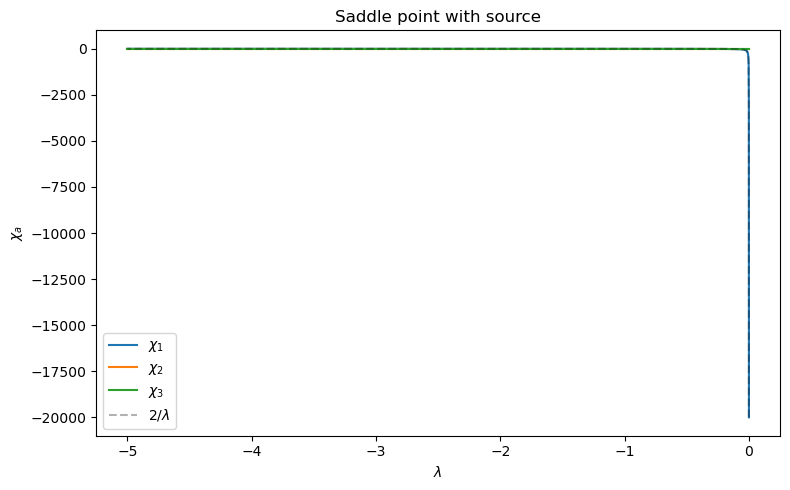

In [3]:
def sbar_example(lam):
    return np.array([0.1, 0.01 * lam, 0.0])

sp_solver2 = sf.SaddlePointSolver(
    sbar_example, lam_span=(-1e-4, -5.0),
    n_fields=3, y1_init=2.0,
    rtol=1e-10, atol=1e-12,
)
sp_result2 = sp_solver2.solve()

fig, ax = plt.subplots(figsize=(8, 5))
labels = [r'$\chi_1$', r'$\chi_2$', r'$\chi_3$']
for a in range(3):
    ax.plot(sp_result2.lam, sp_result2.chi[a], label=labels[a])
ax.plot(sp_result2.lam, 2.0 / sp_result2.lam, 'k--', alpha=0.3, label=r'$2/\lambda$')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\chi_a$')
ax.legend()
ax.set_title('Saddle point with source')
plt.tight_layout()
plt.show()

## 3. Full-sky evolution

Generate correlated Gaussian source fields on the sphere and evolve the fluctuation equation.

In [4]:
import healpy as hp

# Define a simple power spectrum: C_l^{aa} = A / (l + 1)^2
def cl_func(lam):
    lmax = 96  # 3*nside - 1 for nside=32
    ell = np.arange(lmax + 1)
    # Amplitude grows with |lambda|
    amp = 1e-4 * (1.0 + abs(lam))
    cl = amp / (ell + 1.0)**2
    cl[0] = 0.0  # no monopole
    cl_11 = cl
    cl_22 = 0.5 * cl  # weaker for field 2
    cl_33 = 0.3 * cl  # weaker for field 3
    return cl_11, cl_22, cl_33

nside = 32
lam_samples = np.linspace(-0.01, -3.0, 30)

# Correlation function in lambda: Gaussian with width sigma_lam
sigma_lam = 0.5
corr_func = lambda dlam: np.exp(-dlam**2 / (2 * sigma_lam**2))

source_fs = sf.FullSkySource(
    cl_func, lam_samples, nside,
    corr_func=corr_func, seed=42, n_fields=3,
)
source_fs.generate()
print(f'Generated {len(lam_samples)} source maps at nside={nside} '
      f'({source_fs.npix} pixels)')

Generated 30 source maps at nside=32 (12288 pixels)


In [5]:
# Solve the full system (linear only for speed)
solver_fs = sf.SachsFieldSolver(
    source_fs,
    lam_span=(-1e-3, -3.0),
    n_fields=3,
    linear_only=True,
    saddle_kwargs=dict(rtol=1e-8, atol=1e-10),
    fluct_kwargs=dict(rtol=1e-6, atol=1e-8, method='RK45'),
)

t_eval = np.linspace(-1e-3, -3.0, 20)
result_fs = solver_fs.solve(t_eval=t_eval)
print('Integration complete.')
print(f'Saddle chi_1 at lam=-3: {result_fs.saddle(-3.0)[0]:.6f} '
      f'(exact 2/lam: {2.0/(-3.0):.6f})')

Integration complete.
Saddle chi_1 at lam=-3: -0.666667 (exact 2/lam: -0.666667)


/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_11718/2232921071.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


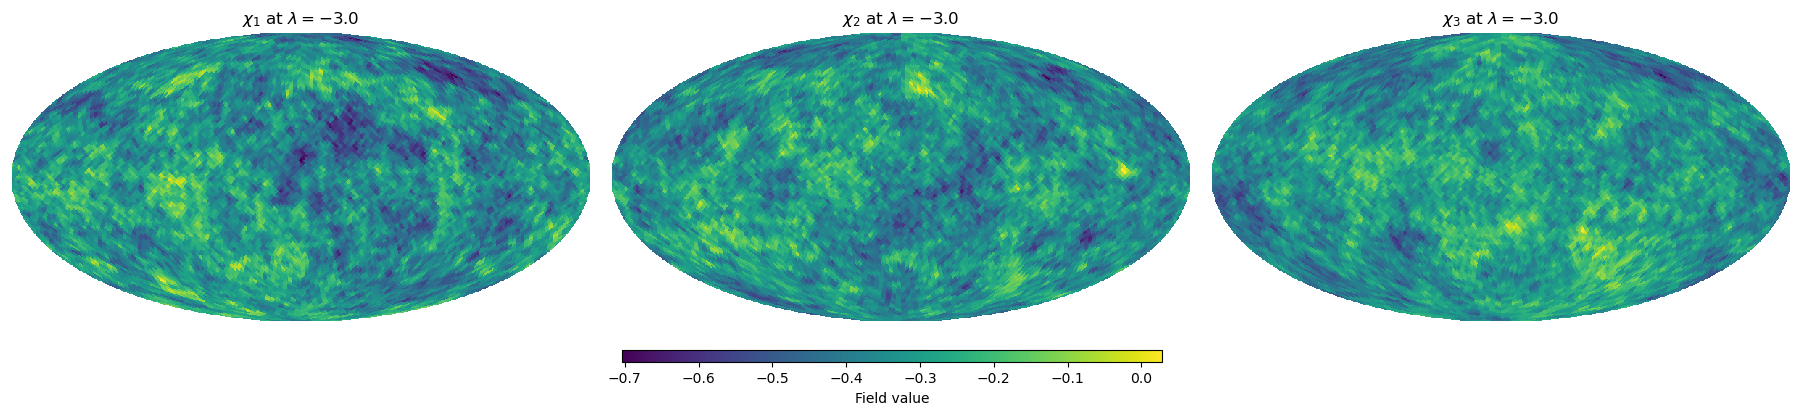

In [6]:
# Visualize the total field at the final time
total = result_fs.total_field(-1)  # (3, npix)

titles = [r'$\chi_1$', r'$\chi_2$', r'$\chi_3$']

fig = plt.figure(figsize=(18, 4))
for a in range(3):
    hp.mollview(
        total[a],
        title=titles[a] + f' at $\lambda={t_eval[-1]:.1f}$',
        sub=(1, 3, a + 1),
        fig=fig.number,
        cmap='viridis',
        min=total[a].min(),
        max=total[a].max(),
        nest=False,
        cbar=False,
    )

# Shared colorbar on the right (anchor to the figure)
cax = fig.add_axes([0.35, 0.03, 0.3, 0.03])
norm = plt.Normalize(vmin=np.min(total), vmax=np.max(total))
cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), cax=cax, orientation='horizontal')
cb.set_label('Field value')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

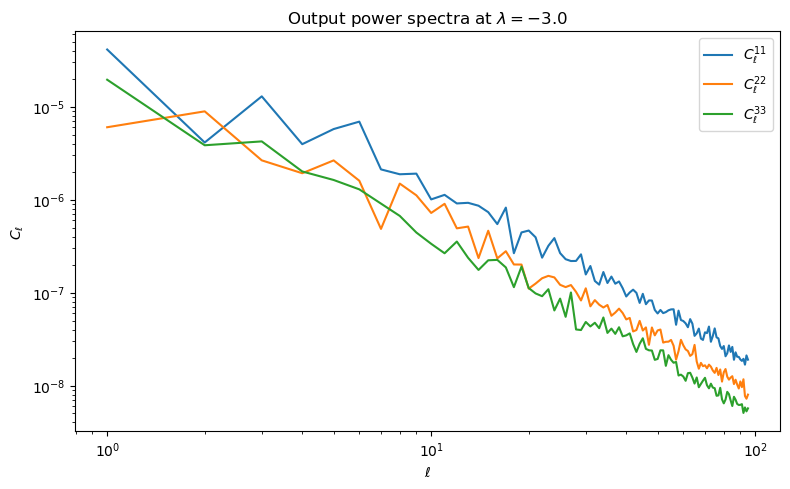

In [7]:
# Output power spectra at final time
cls_out = result_fs.fluctuation.power_spectra_fullsky(-1, nside)

ell = np.arange(len(cls_out[0]))
fig, ax = plt.subplots(figsize=(8, 5))
labels = [r'$C_\ell^{11}$', r'$C_\ell^{22}$', r'$C_\ell^{33}$']
for a in range(3):
    ax.loglog(ell[1:], cls_out[a][1:], label=labels[a])
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$C_\ell$')
ax.legend()
ax.set_title(f'Output power spectra at $\\lambda={t_eval[-1]:.1f}$')
plt.tight_layout()
plt.show()

## 4. Flat-sky evolution

Same physics on a rectangular patch using 2D FFT.

In [8]:
nx, ny = 64, 64
dx = np.radians(5.0) / nx  # 5 degree patch

source_flat = sf.FlatSkySource(
    cl_func, lam_samples, nx, ny, dx,
    corr_func=corr_func, seed=42, n_fields=3,
)
source_flat.generate()

solver_flat = sf.SachsFieldSolver(
    source_flat,
    lam_span=(-1e-3, -3.0),
    n_fields=3,
    linear_only=True,
    saddle_kwargs=dict(rtol=1e-8, atol=1e-10),
    fluct_kwargs=dict(rtol=1e-6, atol=1e-8),
)

result_flat = solver_flat.solve(t_eval=t_eval)
print('Flat-sky integration complete.')

Flat-sky integration complete.


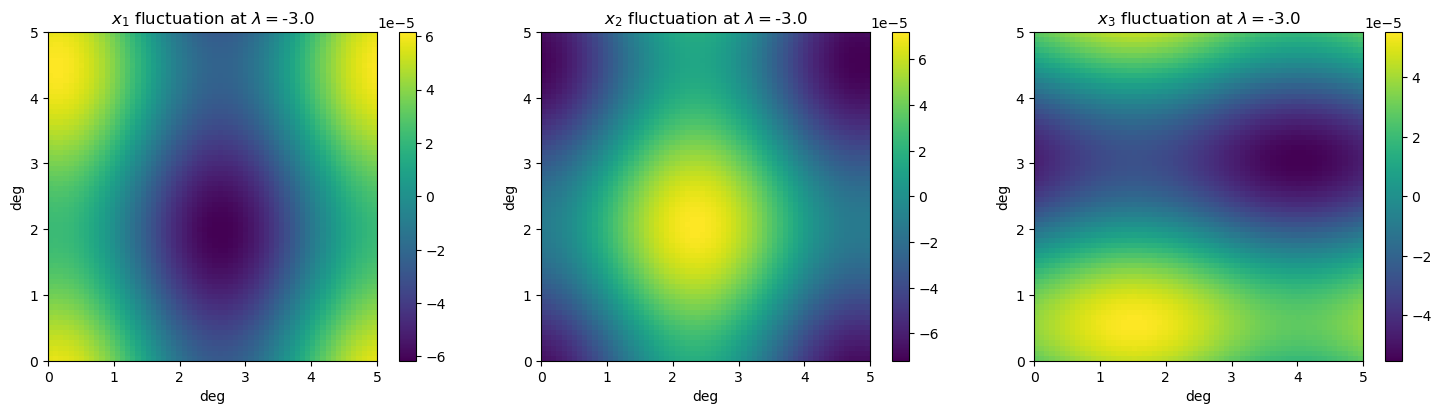

In [9]:
# Visualize flat-sky maps
total_flat = result_flat.total_field(-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = [r'$x_1$', r'$x_2$', r'$x_3$']
for a in range(3):
    # Subtract mean (saddle point) for better visualization of fluctuations
    xi_map = result_flat.fluctuation.xi[-1, a].reshape(nx, ny)
    im = axes[a].imshow(xi_map, origin='lower',
                        extent=[0, np.degrees(nx*dx), 0, np.degrees(ny*dx)])
    axes[a].set_title(titles[a] + r' fluctuation at $\lambda=$' + f'{t_eval[-1]:.1f}')
    axes[a].set_xlabel('deg')
    axes[a].set_ylabel('deg')
    plt.colorbar(im, ax=axes[a])
plt.tight_layout()
plt.show()

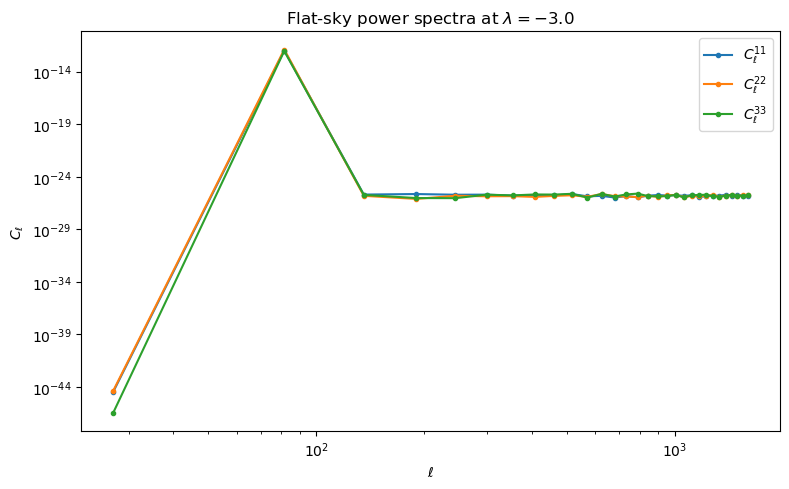

In [10]:
# Flat-sky power spectra
ells_flat, cls_flat = result_flat.fluctuation.power_spectra_flatsky(-1, nx, ny, dx)

fig, ax = plt.subplots(figsize=(8, 5))
labels = [r'$C_\ell^{11}$', r'$C_\ell^{22}$', r'$C_\ell^{33}$']
for a in range(3):
    mask = cls_flat[a] > 0
    ax.loglog(ells_flat[mask], cls_flat[a][mask], 'o-', label=labels[a], markersize=3)
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$C_\ell$')
ax.legend()
ax.set_title(f'Flat-sky power spectra at $\\lambda={t_eval[-1]:.1f}$')
plt.tight_layout()
plt.show()

## 5. Linear vs Nonlinear comparison

Compare evolution with and without the quadratic $F_{abc}\xi_b\xi_c$ term.

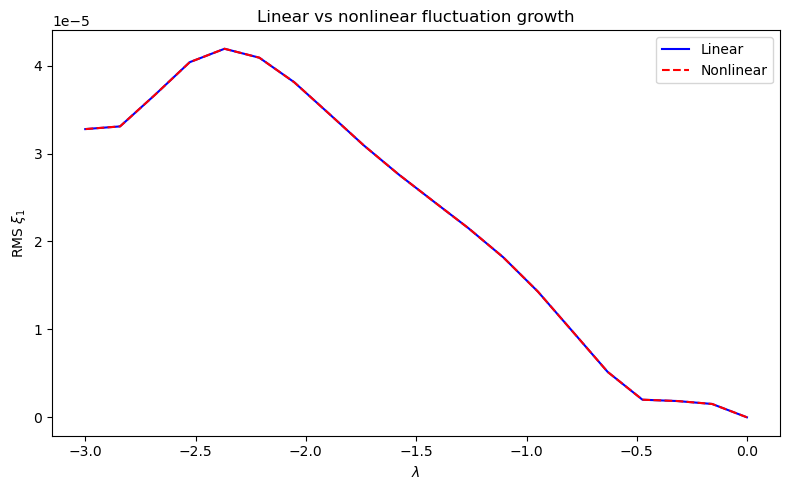

In [11]:
# Nonlinear solve (same source realization)
solver_nl = sf.SachsFieldSolver(
    source_flat,
    lam_span=(-1e-3, -3.0),
    n_fields=3,
    linear_only=False,
    saddle_kwargs=dict(rtol=1e-8, atol=1e-10),
    fluct_kwargs=dict(rtol=1e-6, atol=1e-8),
)
result_nl = solver_nl.solve(t_eval=t_eval)

# Compare RMS of fluctuations over time
rms_lin = np.sqrt(np.mean(result_flat.fluctuation.xi[:, 0, :]**2, axis=1))
rms_nl = np.sqrt(np.mean(result_nl.fluctuation.xi[:, 0, :]**2, axis=1))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_eval, rms_lin, 'b-', label='Linear')
ax.plot(t_eval, rms_nl, 'r--', label='Nonlinear')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'RMS $\xi_1$')
ax.legend()
ax.set_title('Linear vs nonlinear fluctuation growth')
plt.tight_layout()
plt.show()

## 6. Summary Statistics

Use `sf.summary_statistics` to get a combined view: maps, pixel PDF, and angular power spectrum at a single lambda step.

/Users/zzhang/projects/stf-lensing/src-field/notebooks/../sachsfield/utils.py:421: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  fig.tight_layout()


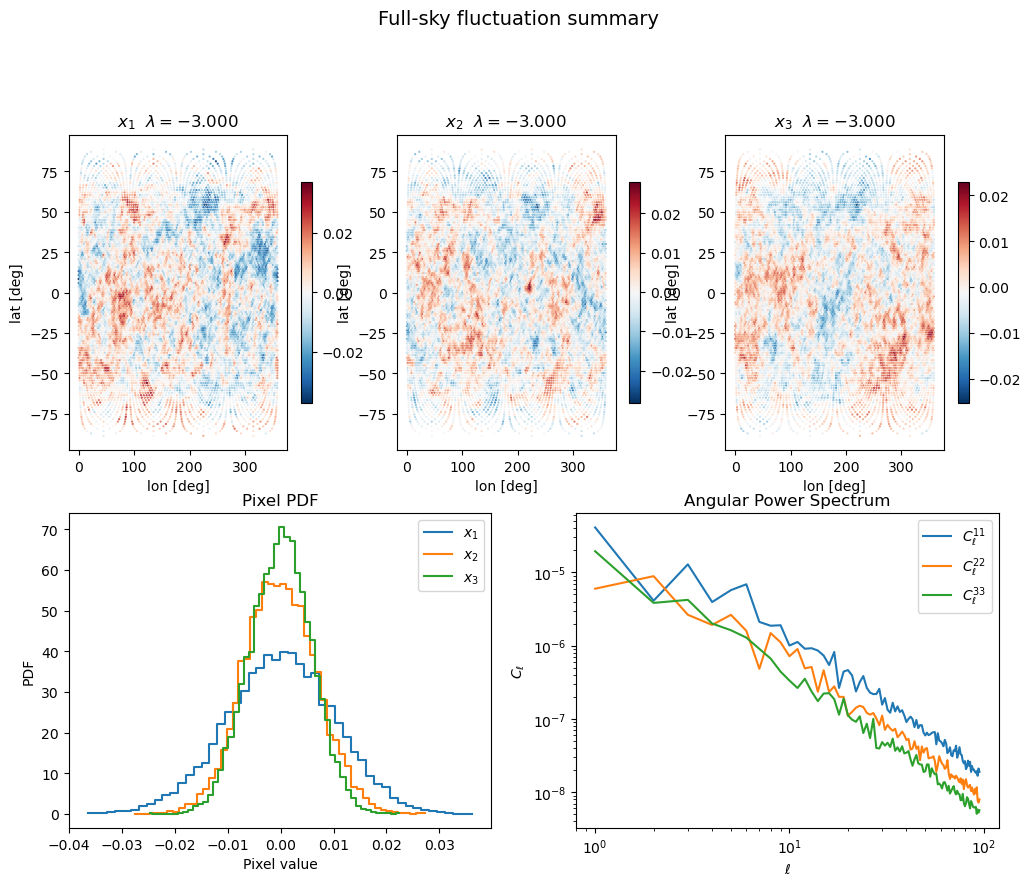

Field 1: mean=-1.45e-19, std=1.01e-02, skew=-0.067, kurtosis=-0.019
Field 2: mean=3.61e-20, std=6.79e-03, skew=0.074, kurtosis=0.040
Field 3: mean=0.00e+00, std=5.78e-03, skew=-0.044, kurtosis=-0.126


In [12]:
# Full-sky summary at the final lambda step (fluctuations only)
fig, stats = sf.summary_statistics(
    result_fs, lam_index=-1,
    mode='fullsky', nside=nside,
    show_saddle=False,
    suptitle='Full-sky fluctuation summary',
)
plt.show()

# Print scalar statistics
for a in range(3):
    print(f'Field {a+1}: mean={stats["mean"][a]:.2e}, '
          f'std={stats["std"][a]:.2e}, '
          f'skew={stats["skew"][a]:.3f}, '
          f'kurtosis={stats["kurtosis"][a]:.3f}')

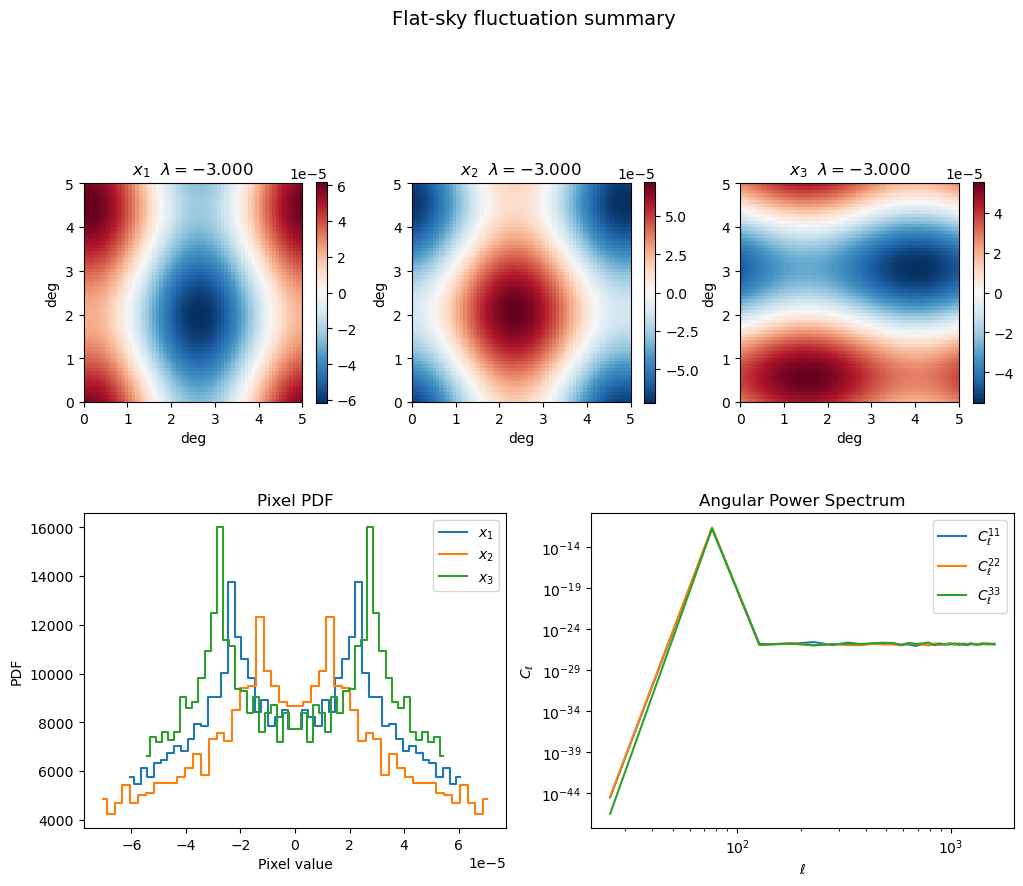

In [13]:
# Flat-sky summary
fig, stats_flat = sf.summary_statistics(
    result_flat, lam_index=-1,
    mode='flatsky', nx=nx, ny=ny, dx=dx,
    show_saddle=False,
    suptitle='Flat-sky fluctuation summary',
)
plt.show()

## 7. Evolution of Summary Statistics

Track how RMS, skewness, and excess kurtosis evolve over lambda.

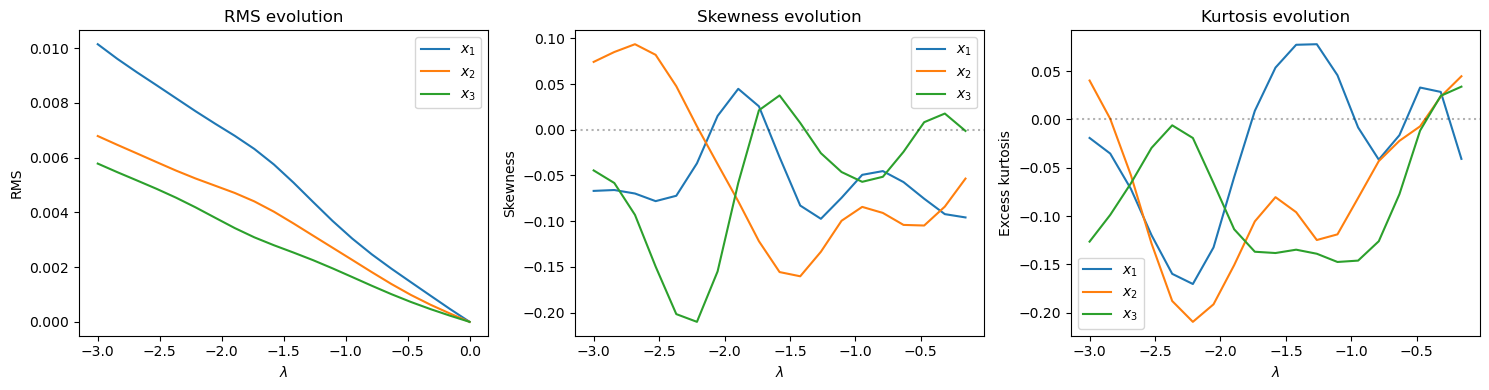

In [14]:
# Evolution of statistics for the full-sky linear run
fig, time_stats = sf.evolution_summary(
    result_fs, mode='fullsky', nside=nside, show_saddle=False,
)
plt.show()

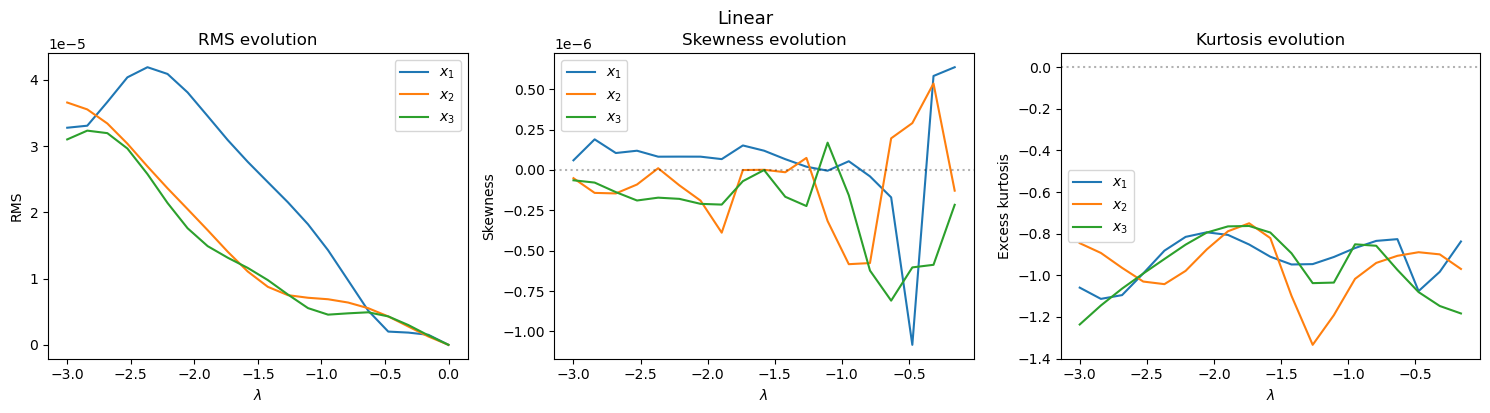

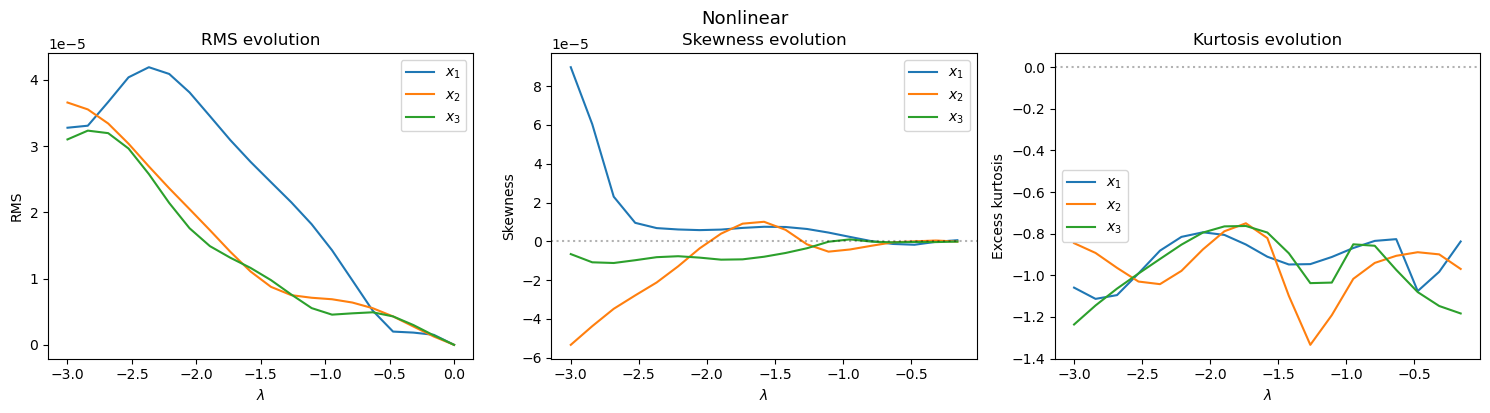

In [15]:
# Compare linear vs nonlinear evolution statistics (flat-sky)
fig_lin, ts_lin = sf.evolution_summary(
    result_flat, mode='flatsky', nx=nx, ny=ny, dx=dx, show_saddle=False,
)
fig_lin.suptitle('Linear', fontsize=13, y=1.02)

fig_nl, ts_nl = sf.evolution_summary(
    result_nl, mode='flatsky', nx=nx, ny=ny, dx=dx, show_saddle=False,
)
fig_nl.suptitle('Nonlinear', fontsize=13, y=1.02)
plt.show()

## 8. Animation

Animate the fluctuation field evolution over lambda steps. (Run in a notebook with `%matplotlib notebook` or save to file.)

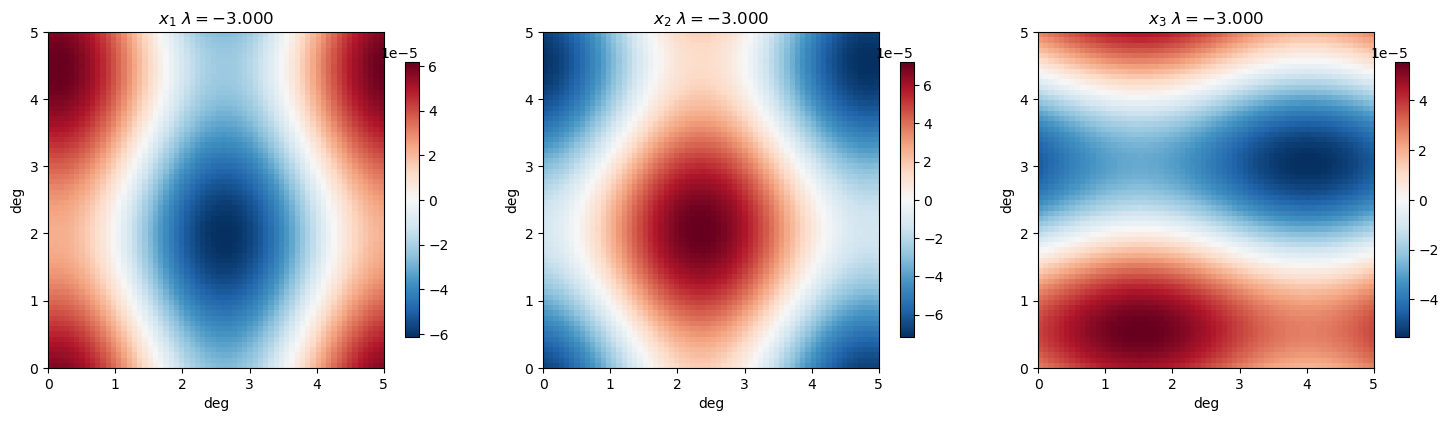

In [16]:
# Flat-sky animation of fluctuations
anim = sf.animate_evolution(
    result_flat,
    mode='flatsky', nx=nx, ny=ny, dx=dx,
    fields=[0, 1, 2],
    show_saddle=False,
    interval=300,
)

# To display inline in Jupyter:
from IPython.display import HTML
HTML(anim.to_jshtml())

# Or save to file:
# anim.save('evolution.mp4', writer='ffmpeg', dpi=150)

## 9. Cosmological Sources with `perFLRW`

Use the `perFLRW` module to derive physical source terms from an FLRW cosmology (via PyCCL), then feed them into `sachsfield`.

**Requires**: `pyccl` installed (e.g., `conda install -c conda-forge pyccl`).

In [17]:
from perFLRW import FLRWCosmology

# Initialize cosmology
flrw = FLRWCosmology(Omega_c=0.25, Omega_b=0.05, h=0.7, sigma8=0.8, n_s=0.96, E_co=1.0)
print(flrw)

FLRWCosmology(Omega_c=0.2500, Omega_b=0.0500, h=0.700, sigma8=0.800, n_s=0.960, E_co=1.0)


### 9a. Affine parameter $\lambda(z)$ and its inverse

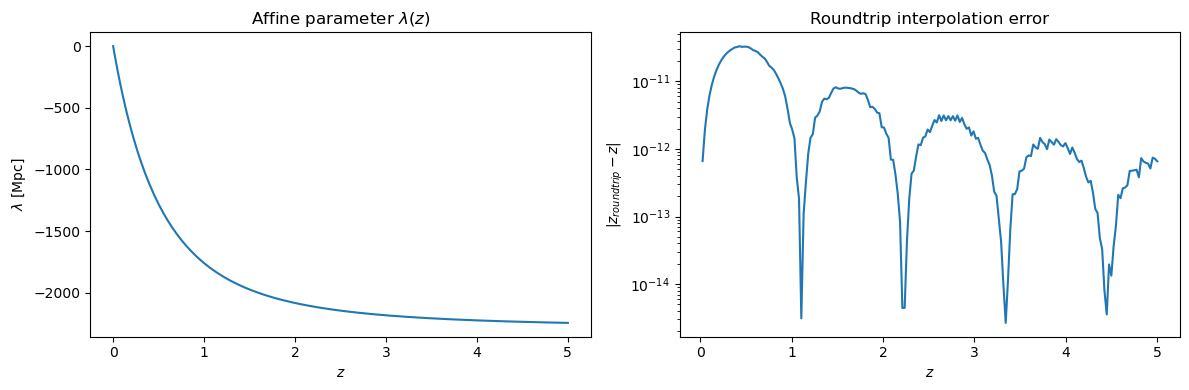

In [18]:
z_arr = np.linspace(0, 5, 200)
lam_arr = flrw.lambda_of_z(z_arr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z_arr, lam_arr)
axes[0].set_xlabel('$z$')
axes[0].set_ylabel(r'$\lambda$ [Mpc]')
axes[0].set_title(r'Affine parameter $\lambda(z)$')

# Roundtrip test
z_back = flrw.z_of_lambda(lam_arr)
axes[1].semilogy(z_arr[1:], np.abs(z_back[1:] - z_arr[1:]))
axes[1].set_xlabel('$z$')
axes[1].set_ylabel('$|z_{roundtrip} - z|$')
axes[1].set_title('Roundtrip interpolation error')

plt.tight_layout()
plt.show()

### 9b. Background $\Phi_{00}(z)$ — Ricci focusing term

$$\Phi_{00} = 4\pi G \, (\rho + P)_{\rm total} \, \left(\frac{E_{\rm co}}{a}\right)^2$$

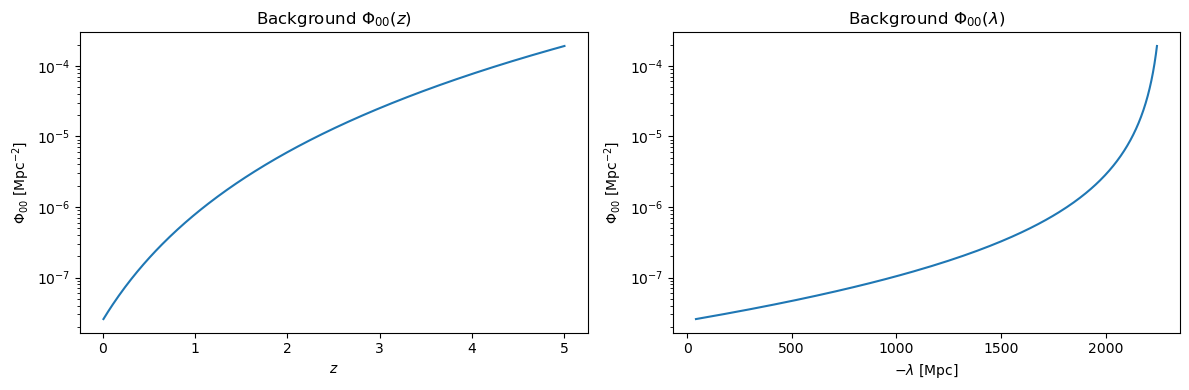

In [19]:
z_dense = np.linspace(0.01, 5, 300)
phi00_bg = flrw.background_phi00(z_dense)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(z_dense, phi00_bg)
axes[0].set_xlabel('$z$')
axes[0].set_ylabel(r'$\Phi_{00}$ [Mpc$^{-2}$]')
axes[0].set_title(r'Background $\Phi_{00}(z)$')

# Same but as function of lambda
lam_dense = flrw.lambda_of_z(z_dense)
phi00_lam = flrw.background_phi00_of_lambda(lam_dense)
axes[1].semilogy(-lam_dense, phi00_lam)
axes[1].set_xlabel(r'$-\lambda$ [Mpc]')
axes[1].set_ylabel(r'$\Phi_{00}$ [Mpc$^{-2}$]')
axes[1].set_title(r'Background $\Phi_{00}(\lambda)$')

plt.tight_layout()
plt.show()

### 9c. Angular power spectra $C_\ell^{\Phi_{00}}$ and $C_\ell^{\Psi_0}$

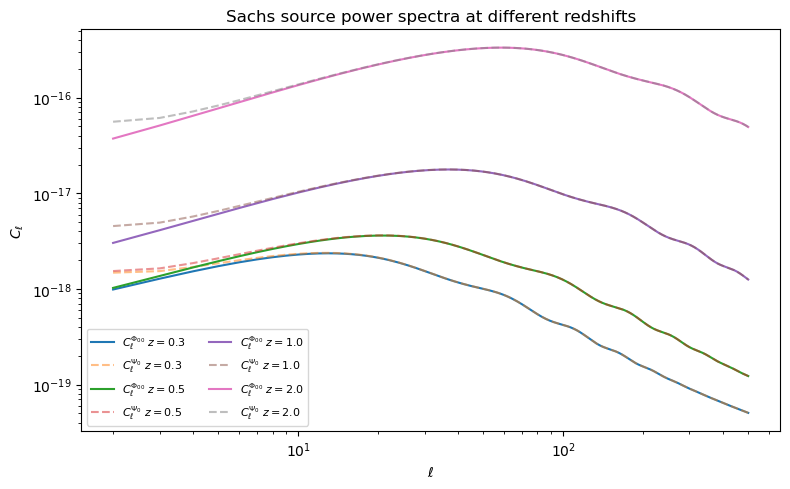

In [20]:
# Power spectra at several redshifts
fig, ax = plt.subplots(figsize=(8, 5))

for z_target in [0.3, 0.5, 1.0, 2.0]:
    ell, cl_phi, cl_psi = flrw.sachs_cls(z_target, lmax=500, delta_z=0.01)
    ax.loglog(ell, cl_phi, label=rf'$C_\ell^{{\Phi_{{00}}}}$ $z={z_target}$')
    ax.loglog(ell, cl_psi, '--', alpha=0.5,
              label=rf'$C_\ell^{{\Psi_0}}$ $z={z_target}$')

ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$C_\ell$')
ax.legend(fontsize=8, ncol=2)
ax.set_title('Sachs source power spectra at different redshifts')
plt.tight_layout()
plt.show()

### 9d. Full pipeline: perFLRW → sachsfield

Generate cosmological source functions and feed them into the Sachs field solver.

In [21]:
# Define the lambda range for evolution
# Pick a redshift range z=0.01 to z=1.5 -> convert to lambda
z_start, z_end = 0.01, 1.5
lam_start = float(flrw.lambda_of_z(z_start))  # near 0, small negative
lam_end = float(flrw.lambda_of_z(z_end))      # more negative
print(f'z=[{z_start}, {z_end}] -> lambda=[{lam_start:.1f}, {lam_end:.1f}] Mpc')

# Get the sachsfield-compatible source callables from cosmology
sbar = flrw.sbar_func(n_fields=3)

# Pre-compute C_l at a grid of redshifts for interpolation
z_grid = np.linspace(z_start, z_end, 20)
nside_cosmo = 16  # small for demo speed
lmax_cosmo = 3 * nside_cosmo - 1

cl_callable = flrw.cl_func(z_array=z_grid, lmax=lmax_cosmo, delta_z=0.01, n_fields=3)

# Test: evaluate at a sample lambda
lam_mid = float(flrw.lambda_of_z(0.5))
cl11, cl22, cl33 = cl_callable(lam_mid)
print(f'C_l at z=0.5: max(cl_11)={cl11.max():.2e}, max(cl_22)={cl22.max():.2e}')

z=[0.01, 1.5] -> lambda=[-42.3, -1974.4] Mpc
C_l at z=0.5: max(cl_11)=3.65e-18, max(cl_22)=3.66e-18


In [22]:
# Generate source fields on the sphere
lam_source_samples = flrw.lambda_of_z(np.linspace(z_start, z_end, 25))

source_cosmo = sf.FullSkySource(
    cl_callable, lam_source_samples, nside_cosmo,
    corr_func=None,  # uncorrelated for simplicity
    seed=123, n_fields=3,
)
source_cosmo.generate()

# Solve the Sachs field evolution with cosmological sources
solver_cosmo = sf.SachsFieldSolver(
    source_cosmo,
    lam_span=(lam_start, lam_end),
    sbar_func=sbar,   # use the cosmological background source
    n_fields=3,
    linear_only=True,
    saddle_kwargs=dict(rtol=1e-8, atol=1e-10),
    fluct_kwargs=dict(rtol=1e-5, atol=1e-7, method='RK45'),
)

t_eval_cosmo = np.linspace(lam_start, lam_end, 15)
result_cosmo = solver_cosmo.solve(t_eval=t_eval_cosmo)
print('Cosmological evolution complete.')

# Check saddle point
z_check = 1.0
lam_check = float(flrw.lambda_of_z(z_check))
chi_at_z1 = result_cosmo.saddle(lam_check)
print(f'chi_1 at z={z_check}: {chi_at_z1[0]:.6e} (2/lam = {2.0/lam_check:.6e})')

Cosmological evolution complete.
chi_1 at z=1.0: -1.309267e-03 (2/lam = -1.136184e-03)


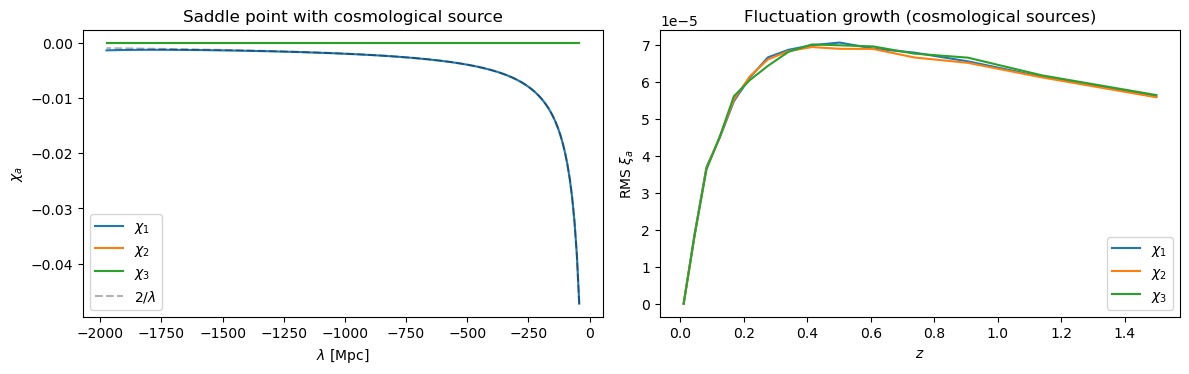

In [23]:
# Visualize: saddle point evolution with cosmological source
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot chi_a(lambda) with z on secondary axis
lam_dense_plot = np.linspace(lam_start, lam_end, 200)
chi_dense = np.array([result_cosmo.saddle(l) for l in lam_dense_plot]).T

labels = [r'$\chi_1$', r'$\chi_2$', r'$\chi_3$']
for a in range(3):
    axes[0].plot(lam_dense_plot, chi_dense[a], label=labels[a])
axes[0].plot(lam_dense_plot, 2.0 / lam_dense_plot, 'k--', alpha=0.3, label=r'$2/\lambda$')
axes[0].set_xlabel(r'$\lambda$ [Mpc]')
axes[0].set_ylabel(r'$\chi_a$')
axes[0].legend()
axes[0].set_title('Saddle point with cosmological source')

# Fluctuation RMS vs redshift
z_eval = flrw.z_of_lambda(t_eval_cosmo)
for a in range(3):
    rms = np.std(result_cosmo.fluctuation.xi[:, a, :], axis=1)
    axes[1].plot(z_eval, rms, label=labels[a])
axes[1].set_xlabel('$z$')
axes[1].set_ylabel(r'RMS $\xi_a$')
axes[1].legend()
axes[1].set_title('Fluctuation growth (cosmological sources)')

plt.tight_layout()
plt.show()

### 9e. Redshift–redshift structure of $C_\ell$

The cross-spectrum $C_\ell^{\Phi_{00}}(z_i, z_j)$ encodes how much two redshift shells share correlated large-scale structure. We compute the full matrix for a grid of redshifts and visualize it at several fixed $\ell$ values.

In [ ]:
# Dense redshift grid for the cross-spectrum matrix
z_grid = np.linspace(0.1, 3.0, 30)

# Compute C_l(z_i, z_j) for Phi_00
# Uses narrow Gaussian shells (delta_z=0.01) at each redshift
ell_cross, cl_matrix = flrw.sachs_cls_cross(
    z_grid, lmax=200, delta_z=0.01, field='phi00'
)
print(f'Cross-spectrum matrix shape: {cl_matrix.shape}')
print(f'ell range: [{ell_cross[0]:.0f}, {ell_cross[-1]:.0f}]')

In [ ]:
# --- Visualise the z-z cross-spectrum at several fixed ell ---
ell_targets = [10, 30, 100]
fig, axes = plt.subplots(1, len(ell_targets), figsize=(5 * len(ell_targets), 4.5))

for ax, ell_t in zip(axes, ell_targets):
    # Find nearest ell index
    idx = np.argmin(np.abs(ell_cross - ell_t))
    mat = cl_matrix[:, :, idx]

    im = ax.pcolormesh(z_grid, z_grid, mat, cmap='inferno', shading='auto')
    ax.set_xlabel(r'$z_i$')
    ax.set_ylabel(r'$z_j$')
    ax.set_title(rf'$C_{{\ell={int(ell_cross[idx])}}}^{{\Phi_{{00}}}}(z_i, z_j)$')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(r'Redshift–redshift structure of $C_\ell^{\Phi_{00}}$', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# --- Correlation coefficient r(z_i, z_j) = C_l(z_i,z_j) / sqrt(C_l(z_i,z_i) * C_l(z_j,z_j)) ---
# This normalises out the amplitude and shows the pure correlation structure

ell_targets_r = [10, 30, 100]
fig, axes = plt.subplots(1, len(ell_targets_r), figsize=(5 * len(ell_targets_r), 4.5))

for ax, ell_t in zip(axes, ell_targets_r):
    idx = np.argmin(np.abs(ell_cross - ell_t))
    mat = cl_matrix[:, :, idx]

    diag = np.diag(mat)
    # Avoid division by zero
    norm = np.sqrt(np.outer(diag, diag))
    norm[norm == 0] = 1.0
    r_mat = mat / norm

    im = ax.pcolormesh(z_grid, z_grid, r_mat, cmap='RdBu_r',
                        vmin=-0.1, vmax=1.0, shading='auto')
    ax.set_xlabel(r'$z_i$')
    ax.set_ylabel(r'$z_j$')
    ax.set_title(rf'$r(\ell={int(ell_cross[idx])})$')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(r'Correlation coefficient $r(z_i, z_j) = C_\ell(z_i,z_j) / \sqrt{C_\ell(z_i) C_\ell(z_j)}$',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# --- Diagonal: auto-spectrum amplitude vs redshift ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: C_l(z, z) as a function of z for several ell
for ell_t in [5, 10, 30, 50, 100]:
    idx = np.argmin(np.abs(ell_cross - ell_t))
    diag = np.array([cl_matrix[i, i, idx] for i in range(len(z_grid))])
    axes[0].semilogy(z_grid, diag, label=rf'$\ell={int(ell_cross[idx])}$')
axes[0].set_xlabel(r'$z$')
axes[0].set_ylabel(r'$C_\ell^{\Phi_{00}}(z, z)$')
axes[0].set_title('Auto-spectrum amplitude vs redshift')
axes[0].legend()

# Right: off-diagonal width (correlation length in z)
# For each ell, measure the FWHM of the correlation along the diagonal
from scipy.interpolate import interp1d

z_ref_idx = len(z_grid) // 2  # reference redshift ~ middle of grid
z_ref = z_grid[z_ref_idx]
corr_widths = []
ell_for_width = ell_cross[::5]  # subsample for speed

for ell_t in ell_for_width:
    idx = np.argmin(np.abs(ell_cross - ell_t))
    row = cl_matrix[z_ref_idx, :, idx]
    peak = cl_matrix[z_ref_idx, z_ref_idx, idx]
    if peak > 0:
        r_row = row / peak
        # Find where correlation drops to 0.5
        above = r_row >= 0.5
        dz_range = z_grid[above]
        if len(dz_range) > 1:
            corr_widths.append(dz_range[-1] - dz_range[0])
        else:
            corr_widths.append(0.0)
    else:
        corr_widths.append(0.0)

axes[1].plot(ell_for_width, corr_widths, 'o-')
axes[1].set_xlabel(r'$\ell$')
axes[1].set_ylabel(r'$\Delta z$ (FWHM of $r$)')
axes[1].set_title(f'Correlation width in $z$ at $z_{{ref}}={z_ref:.1f}$')

plt.tight_layout()
plt.show()